# Part1 Clustering

## Data

In [1]:
import os
os.chdir('./proj2_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project2/proj2_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [3]:
Dataset = "part1_cleaned.csv"
orig_df = pd.read_csv(Dataset)
orig_df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
0,Afghanistan,2017,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,...,6.23,86113314.5,2.120000,7.230000e+08,7.065000e+09,41.53,62.58,12.20,South Asia,Yes
1,Albania,2017,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,...,0.09,1118611.0,3.560000,2.292000e+09,5.271000e+09,58.09,29.97,17.04,Eastern Europe,No
2,Algeria,2017,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,...,0.96,9028313.0,3.950000,3.519100e+10,4.605900e+10,42.79,2.33,1.70,Africa,No
3,American Samoa,2017,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,...,6.23,86113314.5,33.202833,3.970000e+08,5.950000e+08,162.09,4.25,1.99,Australia and Oceanea,No
4,Andorra,2017,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,...,23.25,24238350.0,33.202833,1.180000e+08,1.478000e+09,53.20,4.25,1.99,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Virgin Islands (U.S.),2021,9.43,6.59,2.57,3052.7,103.615,90.00,104.00,57.31,...,6.23,86113314.5,33.202833,6.608000e+09,9.121000e+09,53.03,0.34,0.21,North America,No
1076,West Bank and Gaza,2021,64.93,6.32,6.95,2251.9,117.310,371.97,117.39,1.68,...,1.60,14531924.0,15.110000,6.608000e+09,9.121000e+09,53.03,8.55,3.44,Middle East,No
1077,"Yemen, Rep.",2021,44.42,6.59,2.19,1524.8,124.710,10.63,120.77,1.04,...,6.23,86113314.5,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,Middle East,Yes
1078,Zambia,2021,32.07,3.00,5.11,2525.0,136.310,63.90,127.49,60.03,...,0.95,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,Africa,Yes


## Functions

In [4]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

In [5]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

In [6]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

In [7]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

In [8]:
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()

    # Upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features to drop
    dropped_vars = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop redundant features
    df_reduced = df.drop(columns=dropped_vars)
    
    return df_reduced, dropped_vars

def remove_low_variance(df, threshold=0.01):
    from sklearn.feature_selection import VarianceThreshold

    selector = VarianceThreshold(threshold)
    df_reduced = selector.fit_transform(df)

    kept_vars = df.columns[selector.get_support()]
    kept_vars = kept_vars.tolist()
    
    new_df = pd.DataFrame(df_reduced, columns=kept_vars)
    return new_df, kept_vars

In [9]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute cluster centroids
    centroids = np.array([
        X[labels == k].mean(axis=0) for k in unique_clusters
    ])
    
    from scipy.spatial.distance import cdist
    # Inter-cluster distance (minimum distance between clusters)
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )

    # Intra-cluster distance (maximum cluster diameter)
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

In [10]:
from typing import Tuple
def create_radar_graph(X, X_clusters, size:Tuple[int, int] = (6, 6)):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()
    
    # plot Radar Chart  for cluster means
    labels = cluster_means.columns
    num_features = len(labels)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]
    
    plt.figure(figsize=size)
    
    for i, row in cluster_means.iterrows():
        values = row.tolist()
        values += values[:1]
        plt.polar(angles, values, label=f"Cluster {i}")
    
    plt.xticks(angles[:-1], labels, fontsize=9)
    plt.title("Cluster Profiles (Feature Means)")
    plt.legend()
    if input("save? :").lower() == 'y':
        plt.savefig('../src/radar_graph.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()

    # plot boxplots of feature values 
    for col in X.columns:
        clustered_df.boxplot(column=col, by="Cluster", figsize=(6, 4))
        plt.title(f"{col} by Cluster")
        plt.suptitle("")
        plt.show()

def create_pca_scatterplot(X_scaled, X_clusters):
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(7,5))
    unique_clusters = np.unique(X_clusters)
    for cluster_id in unique_clusters:
        idx = X_clusters == cluster_id
        plt.scatter(X_pca[idx, 0],
                    X_pca[idx, 1],
                    s=40,
                    label=f"Cluster {cluster_id}"
                   )
    
    plt.title("PCA 2D Scatterplot of Clusters")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(title="Cluster ID")
    plt.show()

In [11]:
# permutation importance for regression
def get_permutation_importance(model, X, X_test, y_test):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    if len(X_train) > 200:
        explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    else: 
        explainer = shap.KernelExplainer(model.predict, X_train_df)
    if len(X_test) > 100:
        shap_values = explainer.shap_values(X_test_df.sample(100))
        shap.summary_plot(shap_values, X_test_df.sample(100))
    else:
        shap_values = explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df)

def ols_model(X_true, y_true):
    import statsmodels.api as sm
    X_true_sm = sm.add_constant(X_true)

    # Fit OLS model
    ols_model = sm.OLS(y_true, X_true_sm).fit()

    # Summary table
    print(ols_model.summary())

## Workflow

In [12]:
df = orig_df.copy()
df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
0,Afghanistan,2017,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,...,6.23,86113314.5,2.120000,7.230000e+08,7.065000e+09,41.53,62.58,12.20,South Asia,Yes
1,Albania,2017,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,...,0.09,1118611.0,3.560000,2.292000e+09,5.271000e+09,58.09,29.97,17.04,Eastern Europe,No
2,Algeria,2017,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,...,0.96,9028313.0,3.950000,3.519100e+10,4.605900e+10,42.79,2.33,1.70,Africa,No
3,American Samoa,2017,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,...,6.23,86113314.5,33.202833,3.970000e+08,5.950000e+08,162.09,4.25,1.99,Australia and Oceanea,No
4,Andorra,2017,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,...,23.25,24238350.0,33.202833,1.180000e+08,1.478000e+09,53.20,4.25,1.99,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Virgin Islands (U.S.),2021,9.43,6.59,2.57,3052.7,103.615,90.00,104.00,57.31,...,6.23,86113314.5,33.202833,6.608000e+09,9.121000e+09,53.03,0.34,0.21,North America,No
1076,West Bank and Gaza,2021,64.93,6.32,6.95,2251.9,117.310,371.97,117.39,1.68,...,1.60,14531924.0,15.110000,6.608000e+09,9.121000e+09,53.03,8.55,3.44,Middle East,No
1077,"Yemen, Rep.",2021,44.42,6.59,2.19,1524.8,124.710,10.63,120.77,1.04,...,6.23,86113314.5,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,Middle East,Yes
1078,Zambia,2021,32.07,3.00,5.11,2525.0,136.310,63.90,127.49,60.03,...,0.95,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,Africa,Yes


In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Country Name', 'Region', 'ThirdWorld'], dtype='object')

In [14]:
df['Region'].unique()

array(['South Asia', 'Eastern Europe', 'Africa', 'Australia and Oceanea',
       'Western Europe', 'North America', 'South America', 'Western Asia',
       'Middle East', 'Southeast Asia', 'East Asia', 'Northern Europe',
       'Thailand'], dtype=object)

In [15]:
df = df.drop(['Country Name'], axis=1)
df['ThirdWorld'] = df['ThirdWorld'].map({'no': 0, 'yes': 1, 'No': 0, 'Yes': 1})

In [16]:
encoded_vars = ['Year', 'Region']
df = onehot_encoder_selected(df, encoded_vars)

### Separate input features and output feature

In [17]:
goal = "GNI per capita, PPP (current international $)"
y = orig_df[goal]
y

0        2360.0
1       12800.0
2       13520.0
3       14380.0
4       14380.0
         ...   
1075    14380.0
1076     6800.0
1077    14380.0
1078     3220.0
1079     3220.0
Name: GNI per capita, PPP (current international $), Length: 1080, dtype: float64

In [18]:
X = df.drop([goal], axis=1)
X

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Eastern Europe,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe
0,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,12084.40,652230.0,...,False,False,False,False,False,True,False,False,False,False
1,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,7889.03,27400.0,...,True,False,False,False,False,False,False,False,False,False
2,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,19430.00,2381741.0,...,False,False,False,False,False,False,False,False,False,False
3,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,172.20,200.0,...,False,False,False,False,False,False,False,False,False,False
4,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,160.00,470.0,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,9.43,6.59,2.57,3052.7,103.615,90.00,104.00,57.31,200.60,350.0,...,False,False,True,False,False,False,False,False,False,False
1076,64.93,6.32,6.95,2251.9,117.310,371.97,117.39,1.68,101.40,6025.0,...,False,True,False,False,False,False,False,False,False,False
1077,44.42,6.59,2.19,1524.8,124.710,10.63,120.77,1.04,5490.00,527970.0,...,False,True,False,False,False,False,False,False,False,False
1078,32.07,3.00,5.11,2525.0,136.310,63.90,127.49,60.03,446258.13,743390.0,...,False,False,False,False,False,False,False,False,False,False


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale numberical data

In [20]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

scaler = RobustScaler()
pt = PowerTransformer(method='yeo-johnson')

X_train_scaled = pt.fit_transform(X_train)
X_test_scaled = pt.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Eastern Europe,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe
1009,-1.984480,0.055887,-1.869647,0.010343,-0.038428,0.155973,-0.057873,0.905387,-1.071961,-1.414710,...,-0.299221,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
628,1.124411,0.430713,0.581486,-0.581188,0.140105,-0.145696,-0.037545,-1.242602,-0.191186,0.289337,...,-0.299221,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
644,1.423827,0.118358,-0.080241,-0.438042,1.520214,0.896670,1.465402,-1.545338,-1.260737,-0.787226,...,-0.299221,3.421386,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
884,0.017332,1.556728,1.019805,-0.970635,1.502560,-0.336218,1.164681,0.034557,0.289351,0.166287,...,-0.299221,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
591,1.036491,-0.297365,1.545527,0.870788,1.186429,0.108939,0.563979,0.143505,0.579748,0.445814,...,3.342007,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,0.527317,-0.640954,1.373971,0.029021,-2.108756,0.411740,-1.946087,0.328608,0.173735,-0.049077,...,-0.299221,-0.292279,-0.426547,3.835243,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
466,-0.673217,0.983000,0.346692,0.190692,0.131103,-0.970100,-0.044573,0.602846,1.001206,0.749906,...,-0.299221,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
121,0.003968,1.862343,-0.333210,-0.819381,0.689342,-0.724444,0.611343,-0.771066,0.829318,1.186791,...,-0.299221,-0.292279,-0.426547,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511
1044,-0.547295,-1.190721,0.740134,0.010343,0.360443,-1.442586,0.091084,0.575457,-1.243860,-1.532354,...,-0.299221,-0.292279,2.344406,-0.260740,-0.237139,-0.199277,-0.223199,-0.076294,-0.179605,-0.301511


### Select appropriate selected k

In [21]:
# Construct a kmean clustering model
from sklearn.cluster import KMeans

random_state = 23

def Kmean_cluster(k):
    selected_k = k  # number of resulting clusters
    selected_n_init = 15    # number of times the k-means algorithm is run with different centroid seeds
    model = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=random_state)   
    
    X_clusters_Kmean = model.fit_predict(X_train_scaled)
    return X_clusters_Kmean
#######################################################
    
# Performance Evaluation
def cluster_eva(X_scaled, X_clusters_Kmean):
    silhouette, db, dunn, ch = evaluate_clustering(X_scaled, X_clusters_Kmean)
    print('Selected k: ', k)
    print('Silhouette Index: ', silhouette)
    print('Davies-Bouldin Index: ', db)
    print('Dunn Index: ', dunn)
    print('CH Index: ', ch)

for k in range(2, 11):
    cluster_eva(X_train_scaled, Kmean_cluster(k))

Selected k:  2
Silhouette Index:  0.16569944287991914
Davies-Bouldin Index:  2.092247419780995
Dunn Index:  0.3188152870995712
CH Index:  185.99029283006436
Selected k:  3
Silhouette Index:  0.13929793162123505
Davies-Bouldin Index:  2.2538649724812942
Dunn Index:  0.2350007487750622
CH Index:  145.3203836377374
Selected k:  4
Silhouette Index:  0.1370387342773114
Davies-Bouldin Index:  2.3052386122482424
Dunn Index:  0.27354823805330597
CH Index:  121.30782465919525
Selected k:  5
Silhouette Index:  0.1411476118344974
Davies-Bouldin Index:  2.1034702122648836
Dunn Index:  0.28422030743449933
CH Index:  106.16336388873697
Selected k:  6
Silhouette Index:  0.12891349178897402
Davies-Bouldin Index:  2.08821551189865
Dunn Index:  0.28513877707450624
CH Index:  94.01805269109414
Selected k:  7
Silhouette Index:  0.1277885339452182
Davies-Bouldin Index:  2.167795912107277
Dunn Index:  0.2524058368210948
CH Index:  85.51233905572612
Selected k:  8
Silhouette Index:  0.1169497703133776
Davies

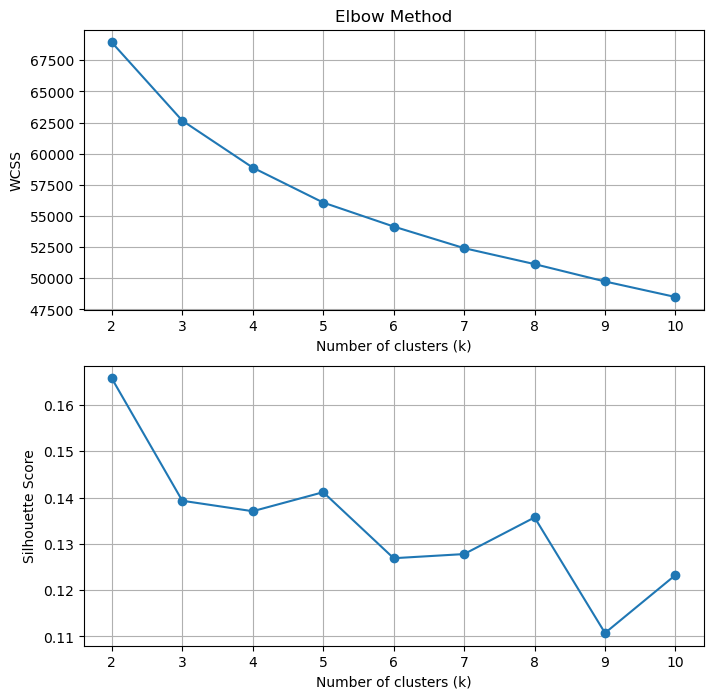

In [22]:
# Construct elbow curve and silhoulette curve to help choose value of k

from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

k_range = range(2, 11)  # silhouette is undefined for k=1

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=random_state)
    temp_X_clusters = kmeans.fit_predict(X_train_scaled)
    
    # Elbow (WCSS)
    wcss.append(kmeans.inertia_)
    
    # Silhouette
    silhouette = silhouette_score(X_train_scaled, temp_X_clusters)
    silhouette_scores.append(silhouette)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.savefig('../src/elbow_and_silhouette.png', dpi=300, bbox_inches='tight')

plt.show()

In [23]:
selected_k = 4
selected_n_init = 15
kmeans = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=random_state)   
X_clusters_Kmean = kmeans.fit_predict(X_train_scaled)

In [24]:
X_train_scaled['Cluster_Label'] = X_clusters_Kmean

X_train_clusters = {}
y_train_clusters = {}

for cluster_id in range(selected_k):
    mask = X_train_scaled['Cluster_Label'] == cluster_id
    X_train_clusters[cluster_id] = X_train_scaled[mask].drop(columns=['Cluster_Label'])
    y_train_clusters[cluster_id] = y_train[mask]

X_train_scaled = X_train_scaled.drop(columns=['Cluster_Label'])

In [25]:
print(f"Total training data size: {len(X_train_scaled)}")
for i in range(selected_k):
    print(f"Cluster {i} size: {len(X_train_clusters[i])} rows")

Total training data size: 864
Cluster 0 size: 174 rows
Cluster 1 size: 238 rows
Cluster 2 size: 192 rows
Cluster 3 size: 260 rows


### Radar graph and box plots

In [26]:
# From author pov these variables explain rural and urban characteristic the most.
selected_vars = [
                'Rural population (% of total population)',
                'Agricultural land (% of land area)',
                'Crop production index (2014-2016 = 100)', 
                'Merchandise trade (% of GDP)',
                'Access to electricity (% of population)',
                ]

save? : n


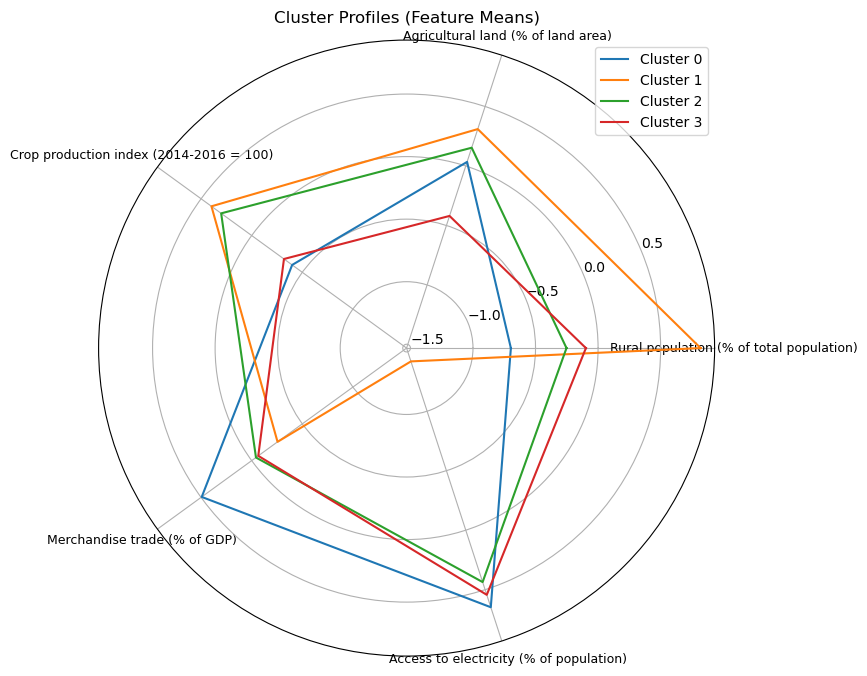

In [27]:
create_radar_graph(X_train_scaled[selected_vars], X_clusters_Kmean, (8, 8))

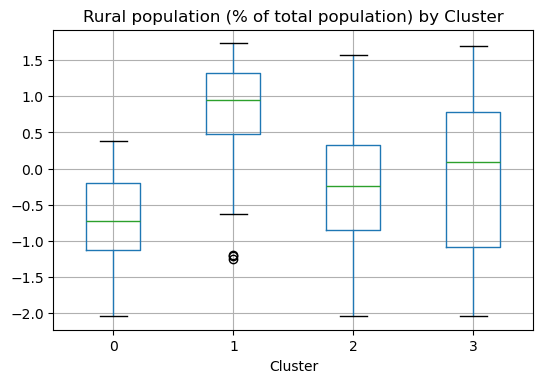

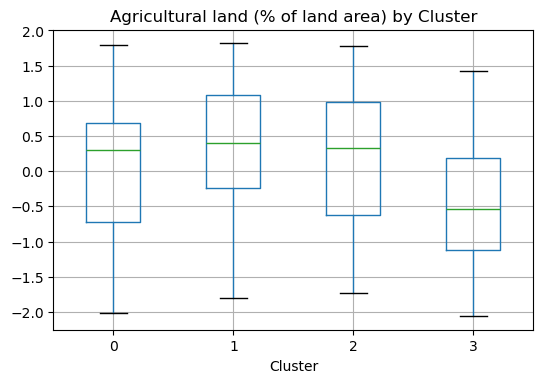

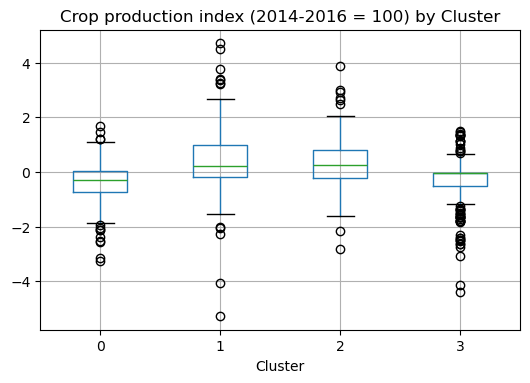

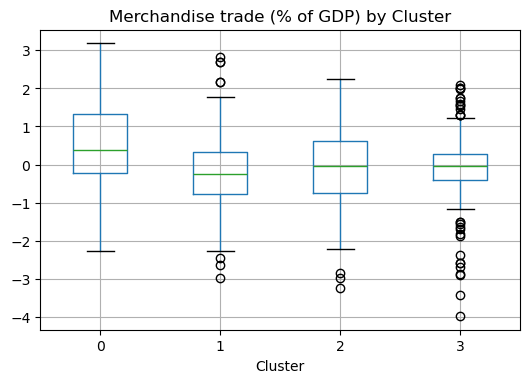

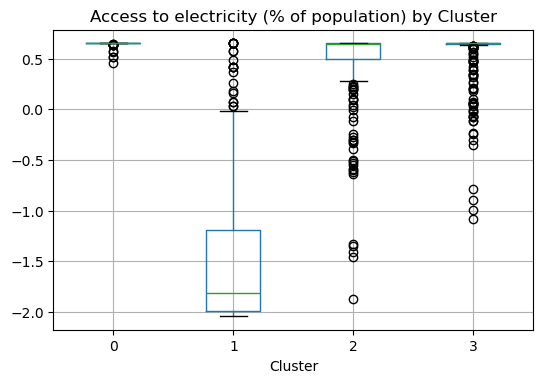

In [28]:
create_feature_boxplots(X_train_scaled[selected_vars], X_clusters_Kmean)

## Setup for regression

In [29]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import root_mean_squared_error, r2_score

random_state=69
cluster_models = {}
cluster_selected_features = {}

### Cluster 0

In [30]:
cluster_id = 0
X_subset = X_train_clusters[cluster_id]
y_subset = y_train_clusters[cluster_id]

X_subset_new, dropped_cols = remove_highly_correlated(X_subset, threshold=0.9)
print(f"Dropped {len(dropped_cols)} highly correlated features")

base_model = Ridge(random_state=random_state)

pipeline = Pipeline([
    ('feature_selection', RFE(estimator=base_model)),
    ('regression', base_model),
])
param_grid = {
    'feature_selection__n_features_to_select': [10, 15, 20, 25, 30, 35, 40, 45, 50],
    'regression__alpha': [0.01, 0.1, 1.0, 10.0]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_subset_new, y_subset)

best_pipeline = grid_search.best_estimator_
best_n_features = grid_search.best_params_['feature_selection__n_features_to_select']
best_alpha = grid_search.best_params_['regression__alpha']

rfe_step = best_pipeline.named_steps['feature_selection']
selected_cols = X_subset_new.columns[rfe_step.support_].tolist()

cluster_selected_features[cluster_id] = selected_cols
cluster_models[cluster_id] = best_pipeline.named_steps['regression']

print(f"Best number of features chosen: {best_n_features}")
print(f"Best Alpha chosen: {best_alpha}")

y_pred_train = best_pipeline.predict(X_subset_new)
rmse_train = root_mean_squared_error(y_subset, y_pred_train)
print(f"Training RMSE: {rmse_train:,.2f}")

Dropped 14 highly correlated features
Best number of features chosen: 40
Best Alpha chosen: 0.1
Training RMSE: 1,901.29


In [31]:
get_permutation_importance(best_pipeline, X_subset_new, X_subset_new, y_subset)

,feature,importance_mean,importance_std
21,GDP (current US$),1.038010,0.072372
17,"Population, total",0.499923,0.023335
61,Merchandise trade (% of GDP),0.468083,0.036414
20,Exports of goods and services (% of GDP),0.365334,0.032533
0,Agricultural land (% of land area),0.125543,0.008710
...,...,...,...
75,Region_North America,0.000000,0.000000
78,Region_South Asia,0.000000,0.000000
76,Region_Northern Europe,0.000000,0.000000
80,Region_Thailand,0.000000,0.000000


### Cluster 1

In [32]:
cluster_id = 1
X_subset = X_train_clusters[cluster_id]
y_subset = y_train_clusters[cluster_id]

X_subset_new, dropped_cols = remove_highly_correlated(X_subset, threshold=0.9)
print(f"Dropped {len(dropped_cols)} highly correlated features")

base_model = Ridge(random_state=random_state)

pipeline = Pipeline([
    ('feature_selection', RFE(estimator=base_model)),
    ('regression', base_model),
])
param_grid = {
    'feature_selection__n_features_to_select': [10, 15, 20, 25, 30, 35, 40, 45, 50],
    'regression__alpha': [0.01, 0.1, 1.0, 10.0]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_subset_new, y_subset)

best_pipeline = grid_search.best_estimator_
best_n_features = grid_search.best_params_['feature_selection__n_features_to_select']
best_alpha = grid_search.best_params_['regression__alpha']

rfe_step = best_pipeline.named_steps['feature_selection']
selected_cols = X_subset_new.columns[rfe_step.support_].tolist()

cluster_selected_features[cluster_id] = selected_cols
cluster_models[cluster_id] = best_pipeline.named_steps['regression']

print(f"Best number of features chosen: {best_n_features}")
print(f"Best Alpha chosen: {best_alpha}")

y_pred_train = best_pipeline.predict(X_subset_new)
rmse_train = root_mean_squared_error(y_subset, y_pred_train)
print(f"Training RMSE: {rmse_train:,.2f}")

Dropped 16 highly correlated features
Best number of features chosen: 50
Best Alpha chosen: 0.01
Training RMSE: 669.53


In [33]:
get_permutation_importance(best_pipeline, X_subset_new, X_subset_new, y_subset)

,feature,importance_mean,importance_std
12,Rural population,5.509615,0.256514
21,GDP (current US$),3.472567,0.142298
72,Region_Middle East,0.562385,0.036589
46,"Life expectancy at birth, female (years)",0.234522,0.012862
31,"Labor force, female (% of total labor force)",0.220602,0.013613
...,...,...,...
74,Region_Northern Europe,0.000000,0.000000
75,Region_South America,0.000000,0.000000
77,Region_Southeast Asia,0.000000,0.000000
78,Region_Thailand,0.000000,0.000000


### Cluster 2

In [34]:
cluster_id = 2
X_subset = X_train_clusters[cluster_id]
y_subset = y_train_clusters[cluster_id]

X_subset_new, dropped_cols = remove_highly_correlated(X_subset, threshold=0.9)
print(f"Dropped {len(dropped_cols)} highly correlated features")

base_model = Ridge(random_state=random_state)

pipeline = Pipeline([
    ('feature_selection', RFE(estimator=base_model)),
    ('regression', base_model),
])
param_grid = {
    'feature_selection__n_features_to_select': [10, 15, 20, 25, 30, 35, 40, 45, 50],
    'regression__alpha': [0.01, 0.1, 1.0, 10.0]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_subset_new, y_subset)

best_pipeline = grid_search.best_estimator_
best_n_features = grid_search.best_params_['feature_selection__n_features_to_select']
best_alpha = grid_search.best_params_['regression__alpha']

rfe_step = best_pipeline.named_steps['feature_selection']
selected_cols = X_subset_new.columns[rfe_step.support_].tolist()

cluster_selected_features[cluster_id] = selected_cols
cluster_models[cluster_id] = best_pipeline.named_steps['regression']

print(f"Best number of features chosen: {best_n_features}")
print(f"Best Alpha chosen: {best_alpha}")

y_pred_train = best_pipeline.predict(X_subset_new)
rmse_train = root_mean_squared_error(y_subset, y_pred_train)
print(f"Training RMSE: {rmse_train:,.2f}")

Dropped 17 highly correlated features
Best number of features chosen: 50
Best Alpha chosen: 0.1
Training RMSE: 2,490.63


In [35]:
get_permutation_importance(best_pipeline, X_subset_new, X_subset_new, y_subset)

,feature,importance_mean,importance_std
49,Population ages 65 and above (% of total popul...,1.107965,0.069651
21,GDP (current US$),0.670473,0.042575
12,Rural population,0.486674,0.042866
43,"Death rate, crude (per 1,000 people)",0.345825,0.018482
8,Forest area (sq. km),0.258423,0.013480
...,...,...,...
67,Region_Africa,0.000000,0.000000
74,Region_South America,0.000000,0.000000
73,Region_Northern Europe,0.000000,0.000000
77,Region_Thailand,0.000000,0.000000


### Cluster 3

In [36]:
cluster_id = 3
X_subset = X_train_clusters[cluster_id]
y_subset = y_train_clusters[cluster_id]

X_subset_new, dropped_cols = remove_highly_correlated(X_subset, threshold=0.9)
print(f"Dropped {len(dropped_cols)} highly correlated features")

base_model = Ridge(random_state=random_state)

pipeline = Pipeline([
    ('feature_selection', RFE(estimator=base_model)),
    ('regression', base_model),
])
param_grid = {
    'feature_selection__n_features_to_select': [10, 15, 20, 25, 30, 35, 40, 45, 50],
    'regression__alpha': [0.01, 0.1, 1.0, 10.0]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_subset_new, y_subset)

best_pipeline = grid_search.best_estimator_
best_n_features = grid_search.best_params_['feature_selection__n_features_to_select']
best_alpha = grid_search.best_params_['regression__alpha']

rfe_step = best_pipeline.named_steps['feature_selection']
selected_cols = X_subset_new.columns[rfe_step.support_].tolist()

cluster_selected_features[cluster_id] = selected_cols
cluster_models[cluster_id] = best_pipeline.named_steps['regression']

print(f"Best number of features chosen: {best_n_features}")
print(f"Best Alpha chosen: {best_alpha}")

y_pred_train = best_pipeline.predict(X_subset_new)
rmse_train = root_mean_squared_error(y_subset, y_pred_train)
print(f"Training RMSE: {rmse_train:,.2f}")

Dropped 9 highly correlated features
Best number of features chosen: 50
Best Alpha chosen: 0.01
Training RMSE: 4,811.51


In [37]:
get_permutation_importance(best_pipeline, X_subset_new, X_subset_new, y_subset)

,feature,importance_mean,importance_std
24,"GNI, PPP (current international $)",1.228021,0.043938
18,"Population, total",0.482072,0.030934
31,"Total reserves (includes gold, current US$)",0.203912,0.015494
9,Land area (sq. km),0.197688,0.012449
33,"Labor force, female (% of total labor force)",0.167803,0.008150
...,...,...,...
80,Region_North America,0.000000,0.000000
82,Region_South America,0.000000,0.000000
85,Region_Thailand,0.000000,0.000000
86,Region_Western Asia,0.000000,0.000000


### Evaluate

In [38]:
# With the helps from gemini and revised by the author
test_cluster_labels = kmeans.predict(X_test_scaled)
X_test_final = X_test_scaled.copy()
X_test_final['Cluster_Label'] = test_cluster_labels

all_test_predictions = pd.Series(index=X_test_scaled.index, dtype=float)

print("Each Cluster RMSE Test")
for cluster_id in range(selected_k):
    mask = X_test_final['Cluster_Label'] == cluster_id
    if not mask.any():
        continue

    X_test_subset = X_test_final[mask].drop(columns=['Cluster_Label'])
    y_test_subset = y_test[mask]
    
    selected_features = cluster_selected_features[cluster_id]
    X_test_subset_reduced = X_test_subset[selected_features]
    
    model = cluster_models[cluster_id]
    predictions = model.predict(X_test_subset_reduced.values)
    all_test_predictions[mask] = predictions
    
    cluster_rmse = root_mean_squared_error(y_test_subset, predictions)
    print(f"Cluster {cluster_id} - RMSE (test_amount={mask.sum()}): {cluster_rmse:,.2f}")

final_rmse = root_mean_squared_error(y_test, all_test_predictions)
final_r2 = r2_score(y_test, all_test_predictions)

print("\nOverall Test Performance")
print(f"Overall Piecewise Test RMSE: {final_rmse:,.2f}")
print(f"Overall Piecewise Test R-squared: {final_r2:.4f}")

Each Cluster RMSE Test
Cluster 0 - RMSE (test_amount=42): 2,583.75
Cluster 1 - RMSE (test_amount=61): 1,460.99
Cluster 2 - RMSE (test_amount=48): 3,405.87
Cluster 3 - RMSE (test_amount=65): 6,707.14

Overall Test Performance
Overall Piecewise Test RMSE: 4,244.53
Overall Piecewise Test R-squared: 0.9585
